
## Question 1: Classification using two methods.



P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  In the above reference, two datasets were created, using red and white wine samples.
  The inputs include objective tests (e.g. PH values) and the output is based on sensory data
  (median of at least 3 evaluations made by wine experts). Each expert graded the wine quality 
  between 0 (very bad) and 10 (very excellent). Now, you are working in a worldwide Liquor store - VinoVault, as a data scientist. Your boss thinks it is toooo expensive to hire wine experts to rate the wine quality, he/she is willing to pay you more bonus ($ 1 million) to build a crazy model to rate red wines, so that he/she can make a decision of prices and storages. Here, I give you the red wine quality dataset, you are going to build two classfication models to classify these red wines to their quality classes. The feature information is as follows.

  Attribute information:

   For more information, if you are interested, read [Cortez et al., 2009].

   Input variables (based on physicochemical tests):
   
   1. - fixed acidity
   2. - volatile acidity
   3. - citric acid
   4. - residual sugar
   5. - chlorides
   6. - free sulfur dioxide
   7. - total sulfur dioxide
   8. - density
   9. - pH
   10. - sulphates
   11. - alcohol
         
   Output variable (based on sensory data): 
   
   12. - quality (score between 0 and 10)
  
  
  
  
  
  
  Remember:

  1. Your boss do not know math or statistics, he/she won't pay you anything if he/she does not know what you are doing. Visualization is your friend.
  2. I already pre-process your data, but you still need to pre-process it to make it useful.
  3. Make sure to comments your code or code cells, for example, you should comment like: ## Here I work on data pre-processing.
  4. Give model evaluations like confusion matrix and so on.
  5. Make comparsion for your two models.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [21]:
# Read the red wine quality data
column_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]

data = pd.read_csv("winequality-red.csv", header=None, names=column_names)
data.head()

# Examine data types, missing values, and basic statistics
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.00000

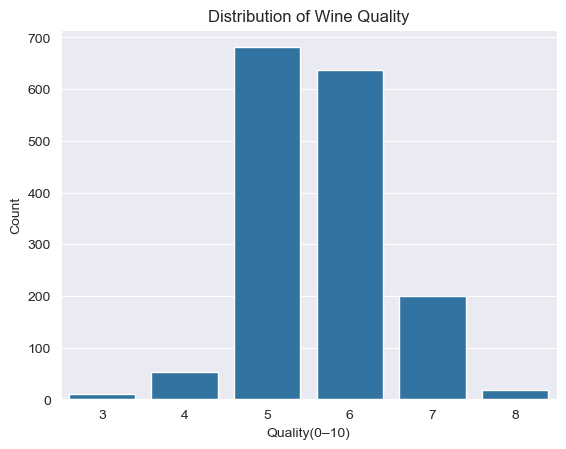

In [22]:
# Visualisation of Red Wine Quality Distribution
plt.figure()
sns.countplot(x="quality", data=data)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality(0–10)")
plt.ylabel("Count")
plt.show()

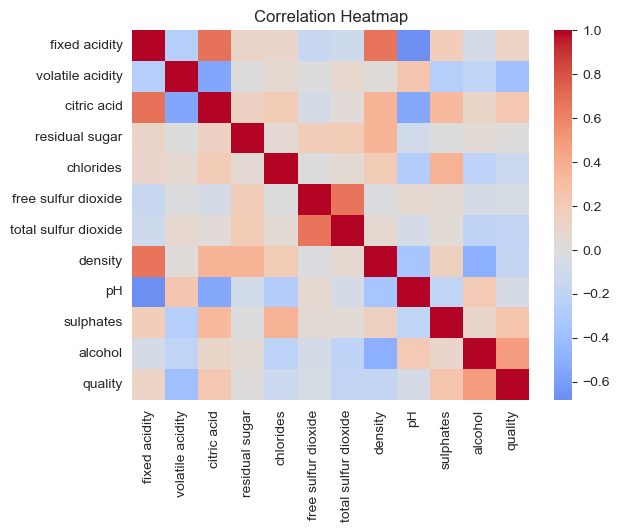

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [23]:
# Feature Correlation Heatmap
plt.figure()
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# View the features most relevant to quality\
corr["quality"].sort_values(ascending=False)

In [24]:
# Split feature X and target y
X = data.drop(columns="quality")
y = data["quality"]

X.shape, y.shape

((1599, 11), (1599,))

In [25]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((1279, 11), (320, 11))

In [26]:
# Model One Logistic Regression
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

# Standardisation
scaler = StandardScaler()

# Fitting Standardiser
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Logistic Regression
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Logistic Regression Accuracy: 0.590625

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



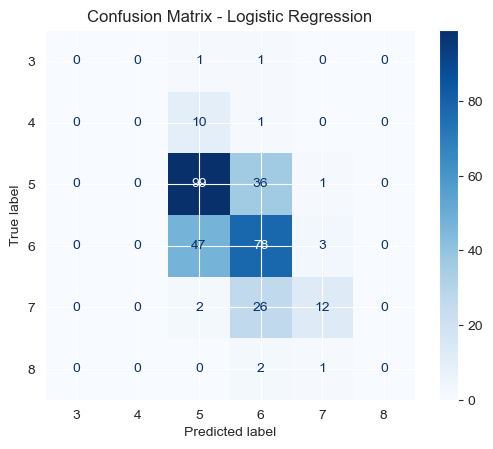

In [27]:
# Test set prediction + evaluation
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:" , accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr,display_labels=sorted(y.unique()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [28]:
# Model Two Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest Accuracy: 0.68125

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



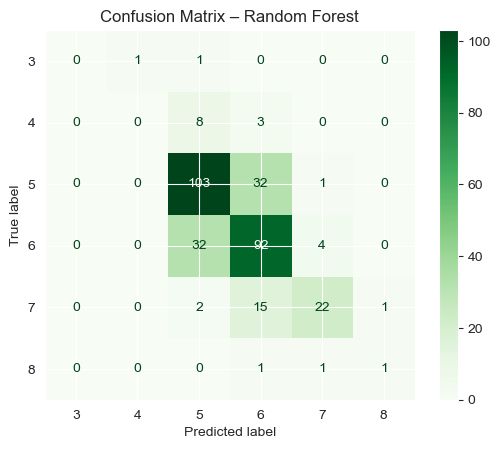

In [29]:
# Random Forest Evaluation
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf,display_labels=sorted(y.unique()))
disp.plot(cmap="Greens")
plt.title("Confusion Matrix – Random Forest")
plt.show()

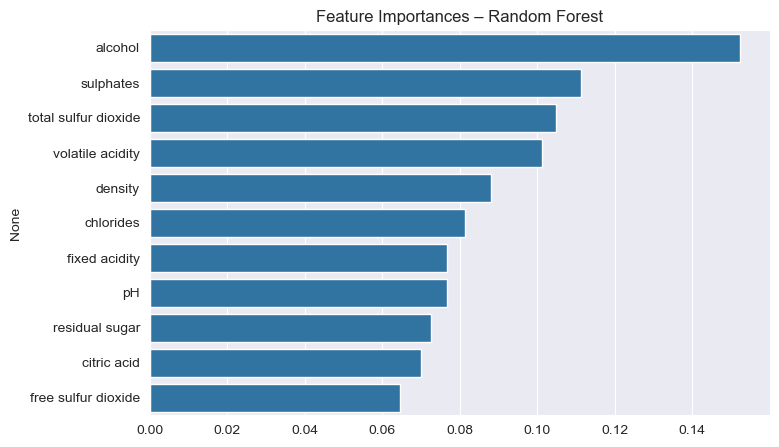

alcohol                 0.152368
sulphates               0.111287
total sulfur dioxide    0.104909
volatile acidity        0.101199
density                 0.088127
chlorides               0.081436
fixed acidity           0.076692
pH                      0.076642
residual sugar          0.072566
citric acid             0.070106
free sulfur dioxide     0.064669
dtype: float64

In [30]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances – Random Forest")
plt.show()

importances

In [31]:
print("Accuracy of Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Accuracy of Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy of Logistic Regression: 0.590625
Accuracy of Random Forest: 0.68125


Random Forest provides higher accuracy and better captures nonlinear relationships in wine characteristics, while Logistic Regression serves as an interpretable baseline; therefore, Random Forest is recommended as the primary prediction model for red wine quality assessment.

## Question 2: Clustering using k-means

Ok, you are doing great! You almost win that bonus. Your boss thinks the wine quality column in your dataset is not realiable, since it is based on some experts. He wants to know if there is a way to cluster these wines based on some similarities. Here you can try to use the k-means to cluster your data (remember to not use the quality column to fit your k-means model and use this column as a test).

C:\Users\LHN10\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\LHN10\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\LHN10\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\LHN10\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

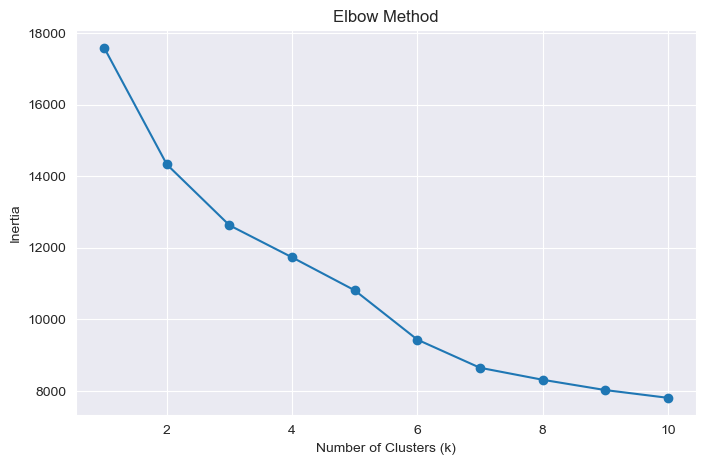

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Read data
data = pd.read_csv("winequality-red.csv")
column_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]

data = pd.read_csv("winequality-red.csv", header=None, names=column_names)

# Remove the quality column
X = data.drop("quality", axis=1)

# Standardise the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Using the Elbow Method to find the optimal k
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [33]:
# Fit K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to your dataframe
data["cluster"] = clusters

data.head()

C:\Users\LHN10\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


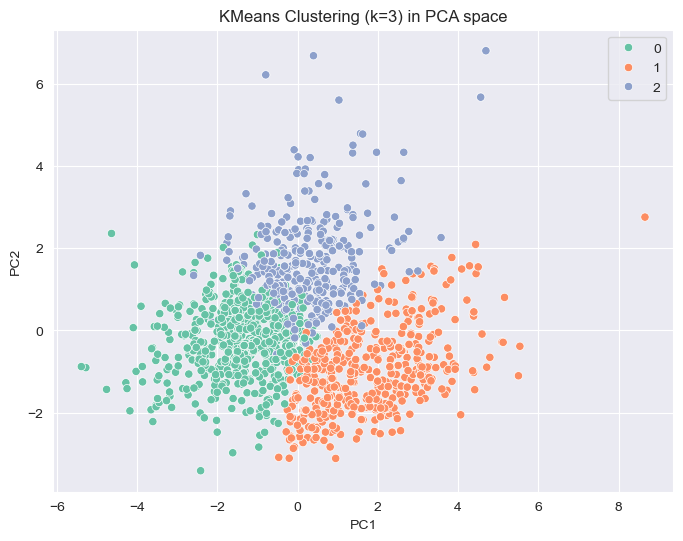

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set2")
plt.title("KMeans Clustering (k=3) in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

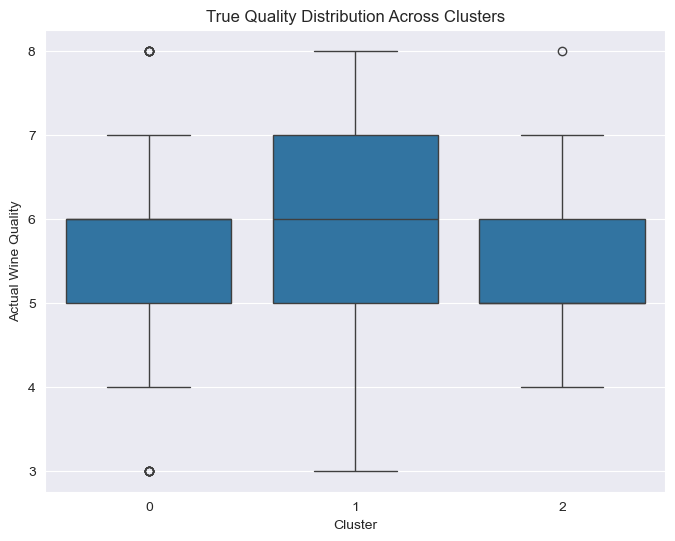

In [35]:
plt.figure(figsize=(8,6))
sns.boxplot(x=clusters, y=data["quality"])
plt.title("True Quality Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Actual Wine Quality")
plt.show()

Using K-means clustering, we standardized all wine features and applied the Elbow Method, which suggested k = 3 as the optimal choice. After fitting the model, PCA visualization showed three clearly separable groups. Comparing these clusters with the actual wine quality (not used during training) revealed that each cluster corresponds to different quality ranges: one group contains lower–medium quality wines, another contains mostly medium–high quality wines, and the third group lies in between. This indicates that K-means can meaningfully group wines based on chemical properties and can serve as a low-cost alternative to expert-based quality evaluation.

Bravo! You are the winner!